# NanoDRR Demo

This notebook demonstrates how to use `nanodrr` for fast DRR rendering from CT volumes.

In [46]:
import matplotlib.pyplot as plt
import torch
import numpy as np
import os
from nanodrr.camera import make_k_inv, make_rt_inv
from nanodrr.data import Subject
from nanodrr.drr import render, DRR
from nanodrr.plot import plot_drr

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## Load Subject

In [95]:
# Use a sample CT from the dataset
# subj_id = "1ABA005"
# subj_id = "1ABB155"
# subj_id = "1BA111"
# subj_id = "1BC025"
# subj_id = "1HNA049"
# subj_id = "1HNC130"
# subj_id = "1PA014"
# subj_id = "1PC057"
# subj_id = "1THA048"
subj_id = "1THB011"


ct_path = f"/gpfs/accounts/jjparkcv_root/jjparkcv98/minsukc/MRI2CT/SynthRAD_combined/1.5mm_registered_flat/{subj_id}/ct.nii"
# seg_path = f"/gpfs/accounts/jjparkcv_root/jjparkcv98/minsukc/MRI2CT/SynthRAD_combined/1.5mm_registered_flat/{subj_id}/ct_seg.nii"

ct_path = "/home/minsukc/MRI2CT/dataset/predictions/1.5x1.5x1.5mm_registered/20260419_0307_amix/epoch_276/pred_1THB011.nii.gz"


subject = Subject.from_filepath(ct_path).to(device)
# subject = Subject.from_filepath(ct_path, seg_path).to(device)
print(f"Subject loaded. Isocenter: {subject.isocenter}")

Subject loaded. Isocenter: tensor([   -8.0000,     8.0000, -1159.5000], device='cuda:0')


## Set up Camera and Render

<Figure size 800x800 with 0 Axes>

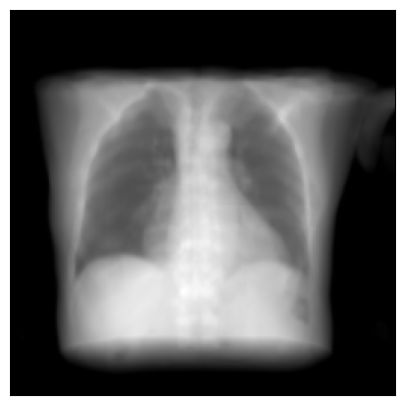

: 

In [ ]:
# Camera parameters
sdd = 1020.0
# delx = dely = 1.0  # 1mm per pixel
delx = dely = 2.0  # 1mm per pixel
x0 = y0 = 0.0
# height = width = 512
height = width = 256

# Construct the inverse intrinsic matrix
k_inv = make_k_inv(sdd, delx, dely, x0, y0, height, width, device=device)
sdd_tensor = torch.tensor([sdd], device=device)

# Construct the inverse extrinsic matrix (AP view)
rt_inv = make_rt_inv(
    torch.tensor([[0.0, 0.0, 0.0]], device=device),  # Rotation (degrees)
    torch.tensor([[0.0, 850.0, 0.0]], device=device),  # Translation (mm)
    orientation="AP",
    isocenter=subject.isocenter,
)

# Render
img = render(subject, k_inv, rt_inv, sdd_tensor, height, width)

# Plot
plt.figure(figsize=(8, 8))
# plot_drr(img.sum(dim=1, keepdim=True), ticks=False)
plot_drr(img, ticks=False)
plt.show()

## Multi-angle Sweep

<Figure size 2000x1000 with 0 Axes>

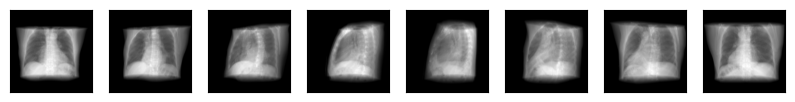

In [90]:
thetas = torch.linspace(0, 180, 8, device=device)
rotations = torch.stack([thetas, torch.zeros_like(thetas), torch.zeros_like(thetas)], dim=1)
translations = torch.tensor([[0.0, 850.0, 0.0]], device=device).repeat(len(thetas), 1)

rt_inv_multi = make_rt_inv(
    rotations,
    translations,
    orientation="AP",
    isocenter=subject.isocenter,
)

imgs_multi = render(subject, k_inv, rt_inv_multi, sdd_tensor, height, width)

plt.figure(figsize=(20, 10))
# plot_drr(imgs_multi.sum(dim=1, keepdim=True), ticks=False)
plot_drr(imgs_multi, ticks=False)
plt.show()

## Segmented DRR
If a labelmap was provided, the output has multiple channels.

Image shape with labels: torch.Size([1, 1, 256, 256])


<Figure size 800x800 with 0 Axes>

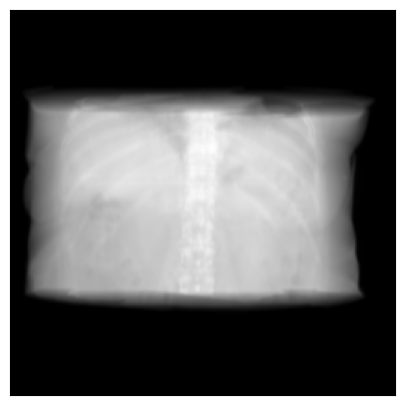

In [53]:
print(f"Image shape with labels: {img.shape}")
# plot_drr can handle multi-channel images by overlaying colors
plt.figure(figsize=(8, 8))
plot_drr(img, ticks=False)
plt.show()

### Vivek's Code

In [22]:
import matplotlib.pyplot as plt
import torch

from nanodrr.camera import make_k_inv, make_rt_inv
from nanodrr.data import Subject, download_deepfluoro
from nanodrr.plot import plot_drr
from nanodrr.drr import render

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [23]:
# Load the volume
# IMAGEPATH = "YOUR_IMAGEPATH_HERE"
# subject = Subject.from_filepath(IMAGEPATH).to(device)

# Load the volume and (optional) segmentation
imagepath, labelpath = download_deepfluoro(subject=1)
# subject = Subject.from_filepath(imagepath, labelpath).to(device)
subject = Subject.from_filepath(imagepath).to(device)

In [40]:
# Construct the inverse intrinsic matrix from C-arm imaging parameters
sdd = 1020.0
delx = dely = 2.0
x0 = y0 = 0.0
height = width = 200
# sdd = 1020.0
# delx = dely = 2.0
# x0 = y0 = 0.0
# height = width = 200

k_inv = make_k_inv(sdd, delx, dely, x0, y0, height, width, device=device)
sdd = torch.tensor([sdd], device=device)

# Construct the inverse extrinsic matrix
rt_inv = make_rt_inv(
    torch.tensor(
        [
            [0.0, 0.0, 0.0],
            [90.0, 0.0, 0.0],
        ],
        device=device,
    ),
    torch.tensor(
        [
            [0.0, 850.0, 0.0],
            [0.0, 850.0, 0.0],
        ],
        device=device,
    ),
    orientation="AP",
    isocenter=subject.isocenter,  # Move to the subject's isocenter
)

In [41]:
# Render the DRR
img = render(subject, k_inv, rt_inv, sdd, height, width)

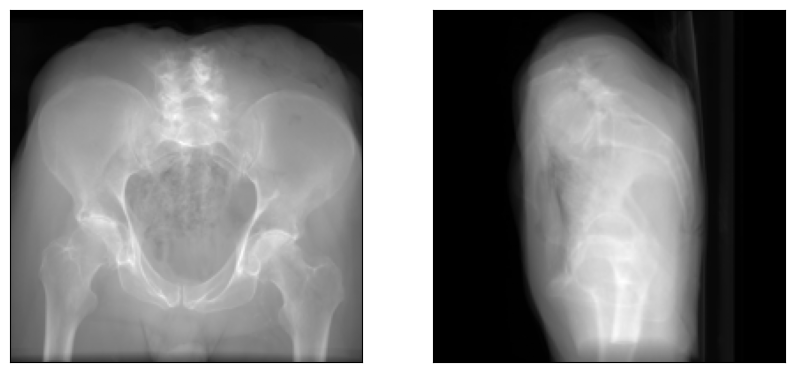

In [42]:
# Plot the DRR and overlay the projected segmentation labels
plot_drr(img, ticks=False)
plt.show()

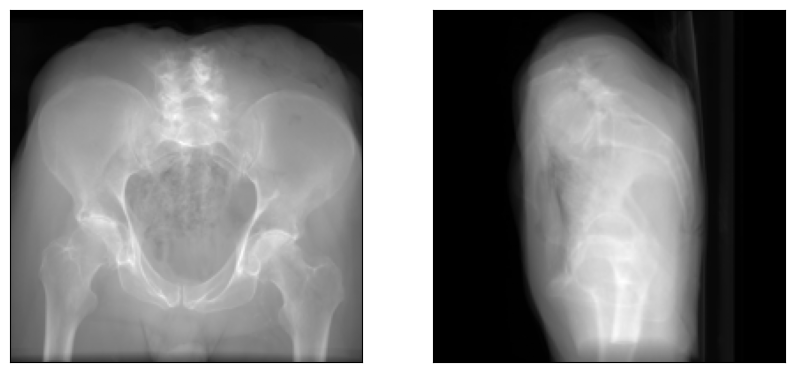

In [43]:
# Sum the intensities across all channels and plot the DRR
plot_drr(img.sum(dim=1, keepdim=True), ticks=False)
plt.show()